# Testing out different metrics and relation to unbalanced data.

Inspired by a [LinkedIn post](https://www.linkedin.com/posts/janosch-menke_no-more-roc-auc-this-has-been-said-activity-7369354684425199616-ggfs?utm_source=share&utm_medium=member_desktop&rcm=ACoAADSwFmwBA-RqFPJR2oeM4IvBokcsgcBatew), in this notebook, we have a look at how robust our classification metrics to evaluate [our hERG model](https://github.com/coreytaylorcompchem/comp_chem/blob/main/ml/adme_models/herg/2025-08-08_ml_hERG.ipynb) really are.

In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    matthews_corrcoef, f1_score, accuracy_score
)
import random
import torch
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm, NNConv
from torch_geometric.data import Data, Dataset, DataLoader
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from rdkit import Chem
from sklearn.model_selection import train_test_split

import pathlib
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
target = 'herg'
uniprot = 'Q12809'

In [3]:
# define paths
HERE = Path(pathlib.Path.cwd())
DATA = HERE / f"data_{target}"
DATA.mkdir(parents=True, exist_ok=True)

In [4]:
# Load chembl data

df = pd.read_csv(f'{DATA}/{target}_chembl.csv',index_col=None)
df['herg_active'] = np.where(df['pIC50'] > 5, 1, 0) # 1=active, 0=inactive @ 10 uM
df.head(20)

,Index,molecule_chembl_id,IC50,units,smiles,pIC50,herg_active
0,0,CHEMBL443476,88.0,nM,O=C1NCCN1CCN1CCC(c2cn(-c3ccccc3)c3ccc(Cl)cc23)CC1,7.055517,1
1,1,CHEMBL53661,137.0,nM,O=C1NCCN1CCN1CCC(c2cn(C3CCCCC3)c3ccc(Cl)cc23)CC1,6.863279,1
2,2,CHEMBL299390,1480.0,nM,CCC(CC)c1cn(-c2ccc(F)cc2)c2ccc(Cl)cc12,5.829738,1
3,3,CHEMBL12186,10.0,nM,O=C1NCCN1CCN1CC=C(c2cn(-c3ccc(F)cc3)c3ccc(Cl)c...,8.000000,1
4,4,CHEMBL556312,23.5,nM,O=C1NCCN1CCN1CCC(C2CN(c3ccc(F)cc3)c3ccccc32)CC1,7.628932,1
5,5,CHEMBL1729,45.0,nM,COc1cc(N)c(Cl)cc1C(=O)NC1CCN(CCCOc2ccc(F)cc2)C...,7.346787,1
6,6,CHEMBL6966,143.0,nM,COc1ccc(CCN(C)CCCC(C#N)(c2ccc(OC)c(OC)c2)C(C)C...,6.844664,1
7,7,CHEMBL55835,579.0,nM,O=C(O)Cc1ccc(-n2cc(C3CCN(CCN4CCNC4=O)CC3)c3cc(...,6.237321,1
8,8,CHEMBL17157,56.0,nM,CC(C)(C)c1ccc(C(O)CCCN2CCC(C(O)(c3ccccc3)c3ccc...,7.251812,1
9,9,CHEMBL298978,6.2,nM,Fc1ccc(-n2cc(C3CCN(CCN4CCN=C4S)CC3)c3ccccc32)cc1,8.207608,1


Are the data labels balanced? We know they aren't. But how much does does this affect the evaluation metrics we used (AUC-ROC and confusion matrix)?

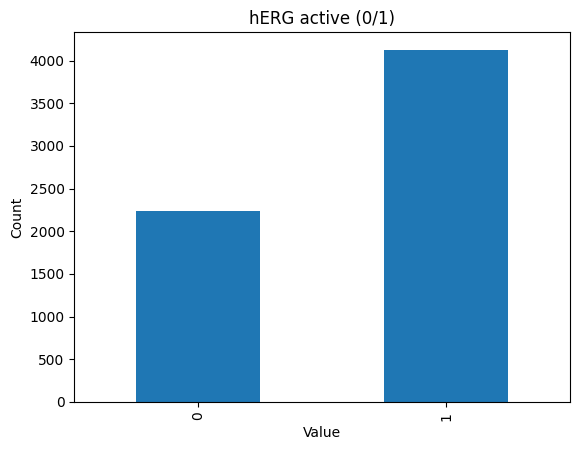

In [5]:
counts = df['herg_active'].value_counts().sort_index()  # ensures 0 comes before 1

counts.plot(kind='bar')
plt.xticks([0, 1], ['0', '1'])
plt.xlabel('Value')
plt.ylabel('Count')
plt.title('hERG active (0/1)')
plt.savefig("herg_active.png", dpi=300)
plt.show()

Let's recreate the plot from the LinkedIn post on our data. First, we need to load some of our model pipeline, so we call it from a local file `herg_pipeline.py`

In [6]:
smiles_list = df.smiles.to_list()
labels = df.herg_active.to_list()

In [ ]:
from herg_pipeline import mol_to_graph, train_with_early_stopping, GCN

In [8]:
data_list = []

for smi, lbl in zip(smiles_list, labels):
    data = mol_to_graph(smi, lbl)
    if data is not None:
        data_list.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list, batch_size=16, shuffle=True)

/home/corey/Documents/comp_chem/ml/adme_models/herg/herg_pipeline.py:61: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor(atom_features, dtype=torch.float)


In [9]:
input_dim = data_list[0].x.shape[1]
edge_dim = data_list[0].edge_attr.shape[1]

And now the plots.

In [10]:
def evaluate_model_imbalance(model, data_list, steps=20, n_repeats=5, batch_size=32):
    pos_data = [d for d in data_list if d.y.item() == 1]
    neg_data = [d for d in data_list if d.y.item() == 0]

    results = []

    for pos_frac in np.linspace(0.01, 0.99, steps):
        for _ in range(n_repeats):
            n_samples = min(len(pos_data), len(neg_data)) * 2
            n_pos = int(pos_frac * n_samples)
            n_neg = n_samples - n_pos

            sampled_pos = random.choices(pos_data, k=n_pos)
            sampled_neg = random.choices(neg_data, k=n_neg)
            sample_data = sampled_pos + sampled_neg
            random.shuffle(sample_data)

            loader = DataLoader(sample_data, batch_size=batch_size)

            y_true = []
            y_scores = []
            y_pred = []

            model.eval()
            with torch.no_grad():
                for batch in loader:
                    batch = batch.to(device)
                    logits = model(batch)
                    probs = torch.sigmoid(logits)
                    preds = (probs > 0.5).float()

                    y_true.extend(batch.y.cpu().numpy())
                    y_scores.extend(probs.cpu().numpy())
                    y_pred.extend(preds.cpu().numpy())

            precision, recall, _ = precision_recall_curve(y_true, y_scores)
            prc_auc = auc(recall, precision)

            metrics = {
                "Positive Class %": round(pos_frac * 100, 2),
                "ROC-AUC": roc_auc_score(y_true, y_scores),
                "PRC-AUC": prc_auc,
                "MCC": matthews_corrcoef(y_true, y_pred),
                "F1 Score": f1_score(y_true, y_pred),
                "Accuracy": accuracy_score(y_true, y_pred)
            }

            results.append(metrics)

    return pd.DataFrame(results)


In [11]:
def plot_metric_vs_imbalance(df_metrics):
    plt.figure(figsize=(14, 8))
    metrics = ["ROC-AUC", "PRC-AUC", "MCC", "F1 Score", "Accuracy"]
    colors = sns.color_palette("tab10", n_colors=len(metrics))

    for metric, color in zip(metrics, colors):
        grouped = df_metrics.groupby("Positive Class %")[metric]
        means = grouped.mean()
        stds = grouped.std()

        plt.errorbar(means.index, means, yerr=stds, label=metric, fmt='-o', color=color, capsize=3)

    plt.xlabel("Positive Class Percentage (%)")
    plt.ylabel("Metric Value")
    plt.title("Classification Metrics vs Class Imbalance: hERG dataset", weight="bold", fontsize=16)
    plt.legend()
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
best_params = {'lr': 0.001, 'hidden_dim': 128, 'pos_weight': None, 'input_dim': 30, 'edge_dim': 6} # these were found during model training.

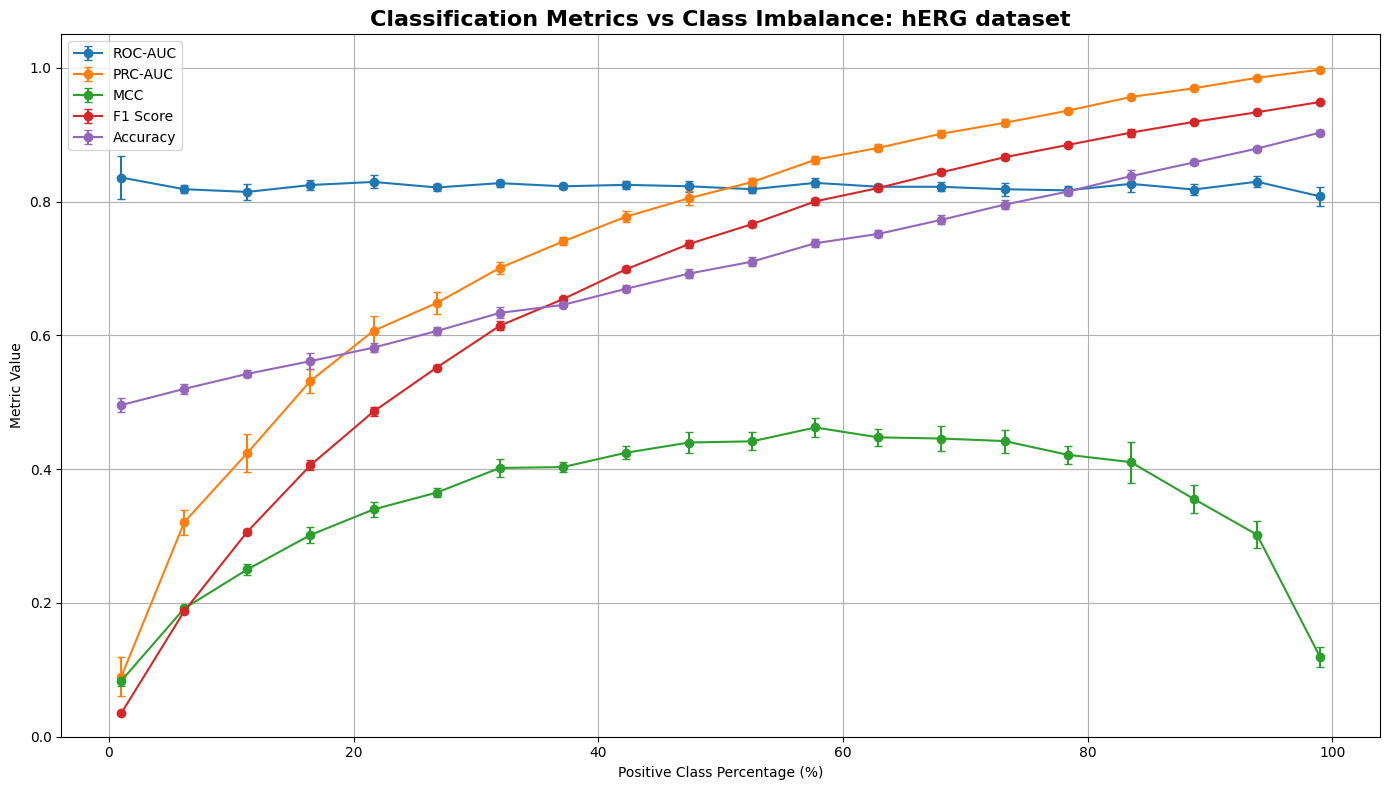

In [13]:
# Reload the trained model
model = GCN(input_dim=input_dim, edge_dim=edge_dim, hidden_dim=best_params['hidden_dim'])
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)

# Evaluate metrics at varying class balances
df_results = evaluate_model_imbalance(model, data_list, steps=20, n_repeats=5)

# Plot
plot_metric_vs_imbalance(df_results)

What is the effect of sample size on these metrics? Do we see a difference?

In [ ]:
# As with training the original model, we do a train/eval split

train_list, val_list = train_test_split(data_list, test_size=0.2, random_state=42, stratify=[d.y.item() for d in data_list])

# train_loader = DataLoader(train_list, batch_size=32, shuffle=True)
# val_loader = DataLoader(val_list, batch_size=32)

In [15]:
def build_data_list_from_df(df, smiles_col="smiles", label_col="herg_active"):
    data_list = []
    for smi, lbl in zip(df[smiles_col], df[label_col]):
        data = mol_to_graph(smi, lbl)
        if data is not None:
            data_list.append(data)
    return data_list


In [17]:
from herg_pipeline import train_with_early_stopping

sample_sizes = [200, 500, 1000]
all_results = []

for n in sample_sizes:
    print(f"\n=== Training on {n} molecules per class ===")
    df_subset = pd.concat([
        df[df['herg_active'] == 0].sample(n=n, random_state=42),
        df[df['herg_active'] == 1].sample(n=n, random_state=42)
    ])
    df_subset = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

    # Build graphs
    data_list = build_data_list_from_df(df_subset)

    # Train/test split
    train_list, val_list = train_test_split(
        data_list, test_size=0.2, random_state=42,
        stratify=[d.y.item() for d in data_list]
    )
    train_loader = DataLoader(train_list, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_list, batch_size=32)

    # Train model
    params = {
        'lr': 0.001,
        'hidden_dim': 128,
        'pos_weight': None,
        'input_dim': data_list[0].x.shape[1],
        'edge_dim': data_list[0].edge_attr.shape[1]
    }

    model = train_with_early_stopping(params, train_loader=train_loader, val_loader=val_loader)

    # Evaluate model across class imbalance
    df_metrics = evaluate_model_imbalance(model, data_list, steps=20, n_repeats=5)
    df_metrics["Train Size"] = n * 2
    all_results.append(df_metrics)



=== Training on 200 molecules per class ===
Epoch 1 | Train Loss: 0.7452 | Val Loss: 0.6955
Epoch 2 | Train Loss: 0.6927 | Val Loss: 0.6915
Epoch 3 | Train Loss: 0.6916 | Val Loss: 0.6907
Epoch 4 | Train Loss: 0.6926 | Val Loss: 0.6916
Epoch 5 | Train Loss: 0.6936 | Val Loss: 0.6893
Epoch 6 | Train Loss: 0.6916 | Val Loss: 0.6891
Epoch 7 | Train Loss: 0.6869 | Val Loss: 0.6921
Epoch 8 | Train Loss: 0.6872 | Val Loss: 0.6877
Epoch 9 | Train Loss: 0.6890 | Val Loss: 0.6874
Epoch 10 | Train Loss: 0.6859 | Val Loss: 0.6874
Epoch 11 | Train Loss: 0.6847 | Val Loss: 0.6961
Epoch 12 | Train Loss: 0.6826 | Val Loss: 0.6885
Epoch 13 | Train Loss: 0.6807 | Val Loss: 0.6874
Epoch 14 | Train Loss: 0.6720 | Val Loss: 0.6865
Epoch 15 | Train Loss: 0.6685 | Val Loss: 0.6929
Epoch 16 | Train Loss: 0.6614 | Val Loss: 0.7025
Epoch 17 | Train Loss: 0.6543 | Val Loss: 0.6972
Epoch 18 | Train Loss: 0.6480 | Val Loss: 0.7161
Epoch 19 | Train Loss: 0.6526 | Val Loss: 0.7112
Epoch 20 | Train Loss: 0.6545 | V

In [18]:
df_all = pd.concat(all_results, ignore_index=True)

df_long = df_all.melt(
    id_vars=["Positive Class %", "Train Size"],
    value_vars=["ROC-AUC", "PRC-AUC", "MCC", "F1 Score", "Accuracy"],
    var_name="Metric",
    value_name="Score"
)

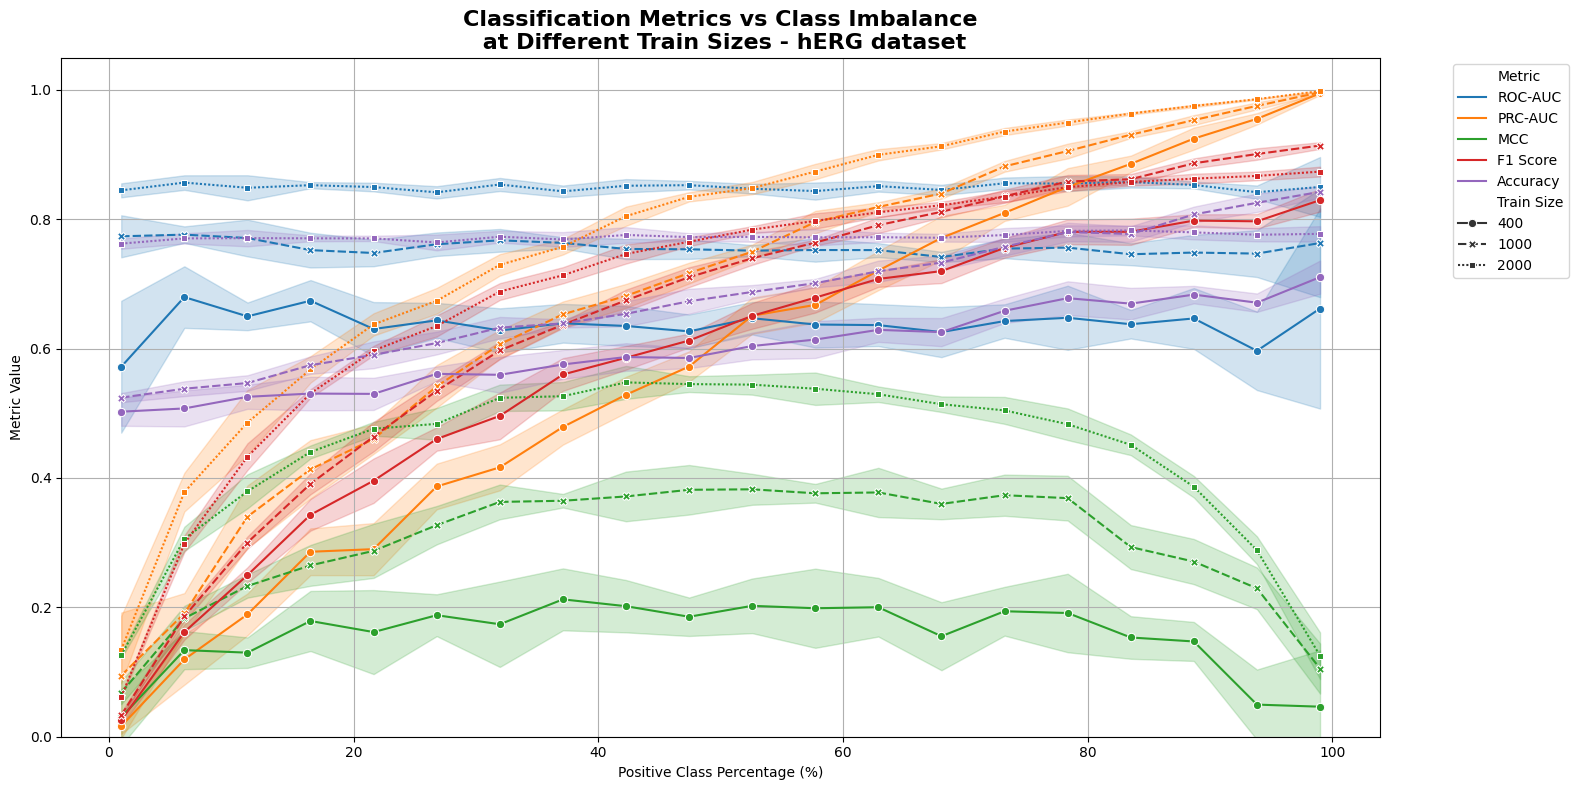

In [19]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_long,
    x="Positive Class %",
    y="Score",
    hue="Metric",
    style="Train Size",
    markers=True,
    dashes=True,
    err_style="band",
    errorbar="sd"
)

plt.title("Classification Metrics vs Class Imbalance\n at Different Train Sizes - hERG dataset", fontsize=16, weight="bold")
plt.ylabel("Metric Value")
plt.xlabel("Positive Class Percentage (%)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Clearly sample size makes quite a difference to performance of all metrics. How about if we take the largest possible balanced sample, then re-run the plot?

In [20]:
# Helper function - take the largets possible balanced sample of the dataset

def get_largest_balanced_sample(df, label_col='herg_active', random_state=42):
    min_class_count = df[label_col].value_counts().min()
    df_balanced = pd.concat([
        df[df[label_col] == 0].sample(n=min_class_count, random_state=random_state),
        df[df[label_col] == 1].sample(n=min_class_count, random_state=random_state)
    ])
    return df_balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)


In [21]:
df_balanced = get_largest_balanced_sample(df)
len(df_balanced)

4480

In [22]:
smiles_list_balanced = df_balanced.smiles.to_list()
labels_balanced = df_balanced.herg_active.to_list()

In [ ]:
data_list_balanced = []

for smi, lbl in zip(smiles_list_balanced, labels_balanced):
    data = mol_to_graph(smi, lbl)
    if data is not None:
        data_list_balanced.append(data)

from torch_geometric.loader import DataLoader

loader = DataLoader(data_list_balanced, batch_size=16, shuffle=True)

In [31]:
input_dim_balanced = data_list_balanced[0].x.shape[1]
edge_dim_balanced = data_list_balanced[0].edge_attr.shape[1]

In [32]:
train_list_balanced, val_list_balanced = train_test_split(data_list_balanced, test_size=0.2, random_state=42, stratify=[d.y.item() for d in data_list_balanced])

# train_loader_balanced = DataLoader(train_list_balanced, batch_size=32, shuffle=True)
# val_loader_balanced = DataLoader(val_list_balanced, batch_size=32)

In [33]:
sample_sizes = [200, 500, 1000]
all_results = []

for n in sample_sizes:
    print(f"\n=== Training on {n} molecules per class ===")
    df_subset = pd.concat([
        df_balanced[df_balanced['herg_active'] == 0].sample(n=n, random_state=42),
        df_balanced[df_balanced['herg_active'] == 1].sample(n=n, random_state=42)
    ])
    df_subset = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

    # Build graphs
    data_list = build_data_list_from_df(df_subset)

    # Train/test split
    train_list, val_list = train_test_split(
        data_list, test_size=0.2, random_state=42,
        stratify=[d.y.item() for d in data_list]
    )
    train_loader_balanced = DataLoader(train_list_balanced, batch_size=32, shuffle=True)
    val_loader_balanced = DataLoader(val_list_balanced, batch_size=32)

    # Train model
    params = {
        'lr': 0.001,
        'hidden_dim': 128,
        'pos_weight': None,
        'input_dim': data_list[0].x.shape[1],
        'edge_dim': data_list[0].edge_attr.shape[1]
    }

    model = train_with_early_stopping(params, train_loader_balanced, val_loader_balanced)

    # Evaluate model across class imbalance
    df_metrics = evaluate_model_imbalance(model, data_list, steps=20, n_repeats=5)
    df_metrics["Train Size"] = n * 2
    all_results.append(df_metrics)



=== Training on 200 molecules per class ===
Epoch 1 | Train Loss: 0.7013 | Val Loss: 0.6810
Epoch 2 | Train Loss: 0.6784 | Val Loss: 0.6646
Epoch 3 | Train Loss: 0.6656 | Val Loss: 0.6819
Epoch 4 | Train Loss: 0.6646 | Val Loss: 0.6497
Epoch 5 | Train Loss: 0.6538 | Val Loss: 0.6501
Epoch 6 | Train Loss: 0.6560 | Val Loss: 0.6478
Epoch 7 | Train Loss: 0.6518 | Val Loss: 0.6572
Epoch 8 | Train Loss: 0.6421 | Val Loss: 0.6350
Epoch 9 | Train Loss: 0.6387 | Val Loss: 0.6298
Epoch 10 | Train Loss: 0.6336 | Val Loss: 0.6264
Epoch 11 | Train Loss: 0.6266 | Val Loss: 0.6345
Epoch 12 | Train Loss: 0.6233 | Val Loss: 0.6216
Epoch 13 | Train Loss: 0.6158 | Val Loss: 0.6206
Epoch 14 | Train Loss: 0.6181 | Val Loss: 0.6267
Epoch 15 | Train Loss: 0.6152 | Val Loss: 0.6302
Epoch 16 | Train Loss: 0.6071 | Val Loss: 0.6188
Epoch 17 | Train Loss: 0.6000 | Val Loss: 0.6144
Epoch 18 | Train Loss: 0.6068 | Val Loss: 0.6170
Epoch 19 | Train Loss: 0.5961 | Val Loss: 0.6117
Epoch 20 | Train Loss: 0.5934 | V

In [34]:
df_all_balanced = pd.concat(all_results, ignore_index=True)

df_long_balanced = df_all_balanced.melt(
    id_vars=["Positive Class %", "Train Size"],
    value_vars=["ROC-AUC", "PRC-AUC", "MCC", "F1 Score", "Accuracy"],
    var_name="Metric",
    value_name="Score"
)

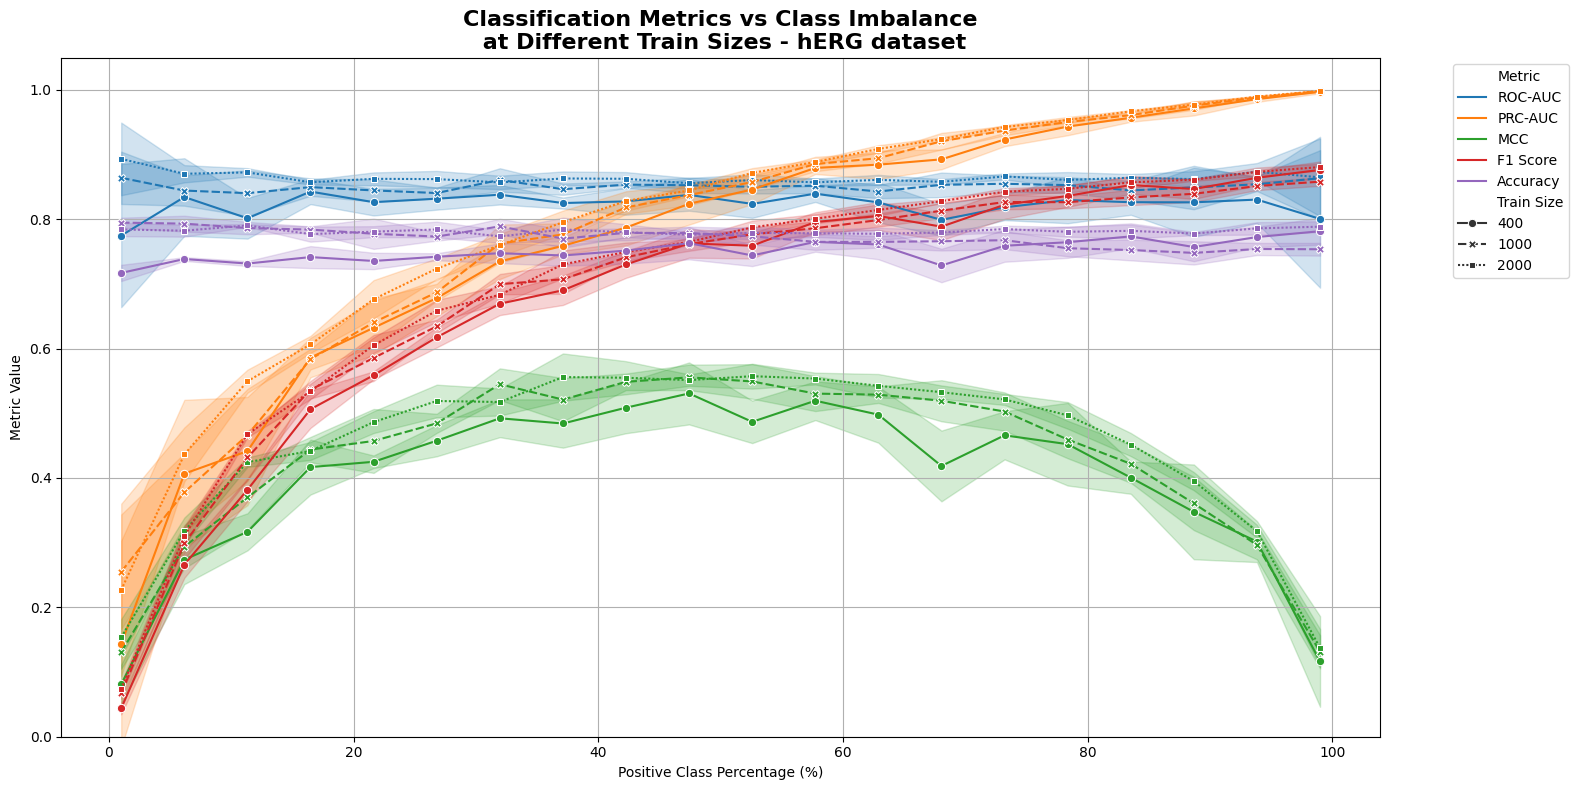

In [35]:
plt.figure(figsize=(14, 8))

sns.lineplot(
    data=df_long_balanced,
    x="Positive Class %",
    y="Score",
    hue="Metric",
    style="Train Size",
    markers=True,
    dashes=True,
    err_style="band",
    errorbar="sd"
)

plt.title("Classification Metrics vs Class Imbalance\n at Different Train Sizes - hERG dataset", fontsize=16, weight="bold")
plt.ylabel("Metric Value")
plt.xlabel("Positive Class Percentage (%)")
plt.ylim(0, 1.05)
plt.grid(True)
plt.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
